In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 6

Cutoff frequency f_c = 10067.89 Hz
Transit frequency f_T = 42547.06 Hz


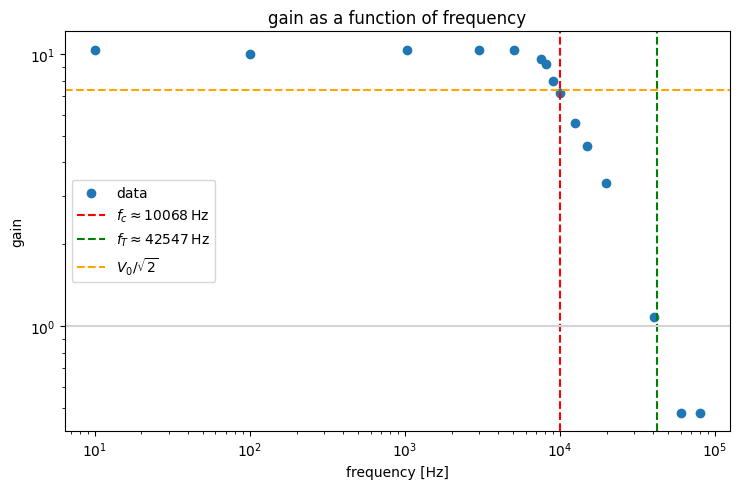

In [8]:
U_in = 1  # V

f = np.array([10, 100, 1025, 3000, 5051, 7500, 8100, 9000, 10000, 12550, 15000, 19800, 40250, 60500, 79750]) # Hz
U_out = np.array([10.4, 10, 10.4, 10.4, 10.4, 9.6, 9.2, 8, 7.2, 5.6, 4.6, 3.36, 1.08, 0.48, 0.48]) # V

V = U_out / U_in
V0 = V[0]
V_boundary= V0 / np.sqrt(2)

###########################
# Code generate by ChatGPT#
###########################
# --- 1) cutoff frequency from linear fit near the -3 dB region ---
mask_cutoff = (f >= 8e3) & (f <= 2e4)   # region around the roll-off start
x1 = np.log10(f[mask_cutoff])
y1 = V[mask_cutoff]

m1, b1 = np.polyfit(x1, y1, 1)          # V = m1*log10(f) + b1
f_c = 10 ** ((V_boundary - b1) / m1)

# --- 2) transit frequency from linear fit in log-log domain ---
mask_transit = f >= 9e3                 # high-frequency falling region
x2 = np.log10(f[mask_transit])
y2 = np.log10(V[mask_transit])

m2, b2 = np.polyfit(x2, y2, 1)          # log10(V) = m2*log10(f) + b2
f_T = 10 ** ((0 - b2) / m2)             # solve for V = 1  -> log10(V)=0

print(f"Cutoff frequency f_c = {f_c:.2f} Hz")
print(f"Transit frequency f_T = {f_T:.2f} Hz")
###########################

# plot
plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.scatter(f, V, label="data")
###########################
# Code generate by ChatGPT#
###########################
plt.axvline(f_c, linestyle="--", color="red", label=fr"$f_c \approx {f_c:.0f}\,\mathrm{{Hz}}$")
plt.axvline(f_T, linestyle="--", color="green", label=fr"$f_T \approx {f_T:.0f}\,\mathrm{{Hz}}$")
plt.axhline(V_boundary, linestyle="--", color="orange", label=r"$V_0/\sqrt{2}$")
plt.axhline(1, color="lightgrey")
###########################

plt.xscale("log")
plt.yscale("log")
plt.xlabel("frequency [Hz]")
plt.ylabel("gain")
plt.title("gain as a function of frequency")
plt.legend()
plt.tight_layout()
plt.savefig('gain_dependency_on_frequency.png', dpi=600)
plt.show()